# $-u'' + u = f$ with Dirichlet conditions, cubic splines

We solve

$$-u''(x) + u(x) = f(x), \quad 0 < x < 1, \qquad u(0) = 0, \quad u(1) = 1,$$

with the exact solution $u(x) = x + \sin(\pi x)$, so that $f(x) = (\pi^2 + 1)\sin(\pi x) + x$.

The weak form is: find $u$ with the boundary values such that

$$\int_0^1 u' v' \, dx + \int_0^1 u v \, dx = \int_0^1 f v \, dx$$

for every test function $v$ that vanishes at both ends.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import D, dx

Cubic splines on 20 equal elements, with Dirichlet conditions at both ends built into the space. `left=` and `right=` give the boundary values, once, with the space.

In [2]:
grid = np.linspace(0, 1, 11)
V = fd.SplineSpace(grid, 3, bc="dirichlet", left=0.0, right=1.0)
u, v = fd.TrialFunction(V), fd.TestFunction(V)

The bilinear form, the right-hand side, and the solve, which takes the boundary values from the space.

In [3]:
f = (np.pi**2 + 1) * fd.sin(np.pi * fd.x) + fd.x

a = D(u) * D(v) * dx + u * v * dx
L = f * v * dx

uh = fd.solve(a, L)

Compare with the exact solution: the maximum error, sampled on 401 points, and the $L^2$ error, $\|u_h - u\|_{L^2} = \left(\int_0^1 (u_h - u)^2\,dx\right)^{1/2}$, integrated by quadrature on each element.

max error: 1.377551939740762e-05
L2 error:  6.545876459953428e-06


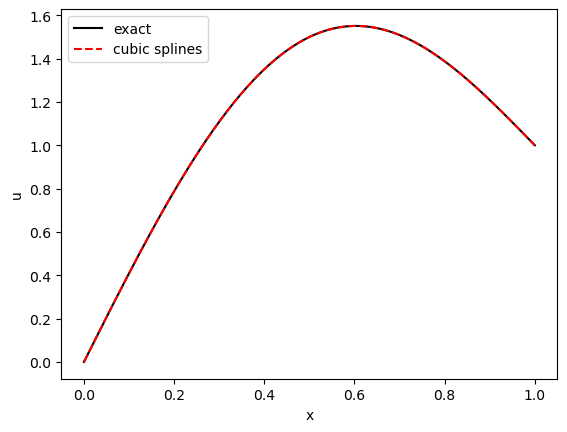

In [4]:
xs = np.linspace(0, 1, 401)
exact = xs + np.sin(np.pi * xs)
errinf = np.max(np.abs(uh(xs) - exact))
print("max error:", errinf)

uex = fd.x + fd.sin(np.pi * fd.x)                 # the exact solution as an expression in x
errL2 = np.sqrt(fd.form((uh - uex)**2 * dx).assemble())
print("L2 error: ", errL2)

plt.plot(xs, exact, "k-", label="exact")
plt.plot(xs, uh(xs), "r--", label="cubic splines")
plt.xlabel("x"); plt.ylabel("u"); plt.legend()
plt.show()